# Multimodal Classification with UPMC Food-101
## Comparing Zero-Shot and Few-Shot Classification using CLIP

This notebook implements a **Multimodal Classification** task (Image + Text) using the UPMC Food-101 dataset.  
We compare **Zero-Shot** and **Few-Shot** classification pipelines using OpenAI's CLIP model and track experiments via **Weights & Biases (W&B)**.

**Key design**: Both zero-shot and few-shot pipelines use *both* image and text modalities for fair comparison.

## 1. Download Dataset

In [3]:
# !pip install kagglehub wandb -q

import kagglehub
root_dir = kagglehub.dataset_download("gianmarco96/upmcfood101")
print("Dataset path:", root_dir)

Dataset path: /home/anhhuy/.cache/kagglehub/datasets/gianmarco96/upmcfood101/versions/1


## 2. Setup & Imports

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import wandb

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPModel, CLIPProcessor
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/home/anhhuy/projects/university/HK252/DL/Assignment1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 3. Custom Dataset & DataLoader

The UPMC Food-101 Kaggle dataset (`gianmarco96/upmcfood101`) is organized as:
- `images/train/<class_name>/<filename>.jpg`  
- `texts/train_titles.csv` — format: `filename, text_title, class_name`

`__getitem__` returns: **(PIL Image, text string, label int)**.

In [4]:
class UPMCFood101KaggleDataset(Dataset):
    """PyTorch Dataset for UPMC Food-101 Kaggle format.
    Returns: (PIL.Image, text_string, label_int)
    """
    def __init__(self, data_list):
        self.data_list = data_list

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        try:
            image = Image.open(item['img_path']).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))

        text = str(item['text']).strip()[:500]
        if len(text) <= 2:
            text = f"A photo of {item['class_name'].replace('_', ' ')}, a delicious food"

        return image, text, item['label']


def load_data_from_csv(csv_path, img_base_dir):
    df = pd.read_csv(csv_path, names=['filename', 'text', 'class_name'])
    df = df.dropna(subset=['class_name'])
    unique_classes = sorted(df['class_name'].unique())
    class_to_idx = {cls: idx for idx, cls in enumerate(unique_classes)}

    data_list = []
    for _, row in df.iterrows():
        class_name = str(row['class_name'])
        data_list.append({
            'img_path': os.path.join(img_base_dir, class_name, str(row['filename'])),
            'text': str(row['text']),
            'label': class_to_idx[class_name],
            'class_name': class_name
        })
    return data_list, unique_classes


train_samples, class_names = load_data_from_csv(
    os.path.join(root_dir, "texts", "train_titles.csv"),
    os.path.join(root_dir, "images", "train")
)
test_samples, _ = load_data_from_csv(
    os.path.join(root_dir, "texts", "test_titles.csv"),
    os.path.join(root_dir, "images", "test")
)

num_classes = len(class_names)
print(f"Classes: {num_classes}  |  Train: {len(train_samples)}  |  Test: {len(test_samples)}")

train_dataset = UPMCFood101KaggleDataset(train_samples)
test_dataset  = UPMCFood101KaggleDataset(test_samples)

def collate_fn(batch):
    images = [b[0] for b in batch]
    texts  = [b[1] for b in batch]
    labels = torch.tensor([b[2] for b in batch])
    return images, texts, labels

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

Classes: 101  |  Train: 67972  |  Test: 22716
Train batches: 2125  |  Test batches: 710


## 4. Exploratory Data Analysis (EDA)

This section aims to analyze and present the multimodal data structure, check class distributions, and analyze text lengths to prepare charts for the presentation slide.

In [5]:
# 1. Dataset Overview
df_train = pd.DataFrame(train_samples)
df_test = pd.DataFrame(test_samples)
class_counts = df_train['class_name'].value_counts()

print("=== Dataset Overview (UPMC Food-101) ===")
print(f"Number of classes: {num_classes}")
print(f"Number of training samples: {len(df_train)}")
print(f"Number of testing samples: {len(df_test)}")
print(f"Average samples per class (train): {class_counts.mean():.1f}")
print(f"Class with minimum samples: {class_counts.idxmin()} ({class_counts.min()} samples)")
print(f"Class with maximum samples: {class_counts.idxmax()} ({class_counts.max()} samples)")

=== Dataset Overview (UPMC Food-101) ===
Number of classes: 101
Number of training samples: 67972
Number of testing samples: 22716
Average samples per class (train): 673.0
Class with minimum samples: lobster_bisque (591 samples)
Class with maximum samples: macaroni_and_cheese (713 samples)


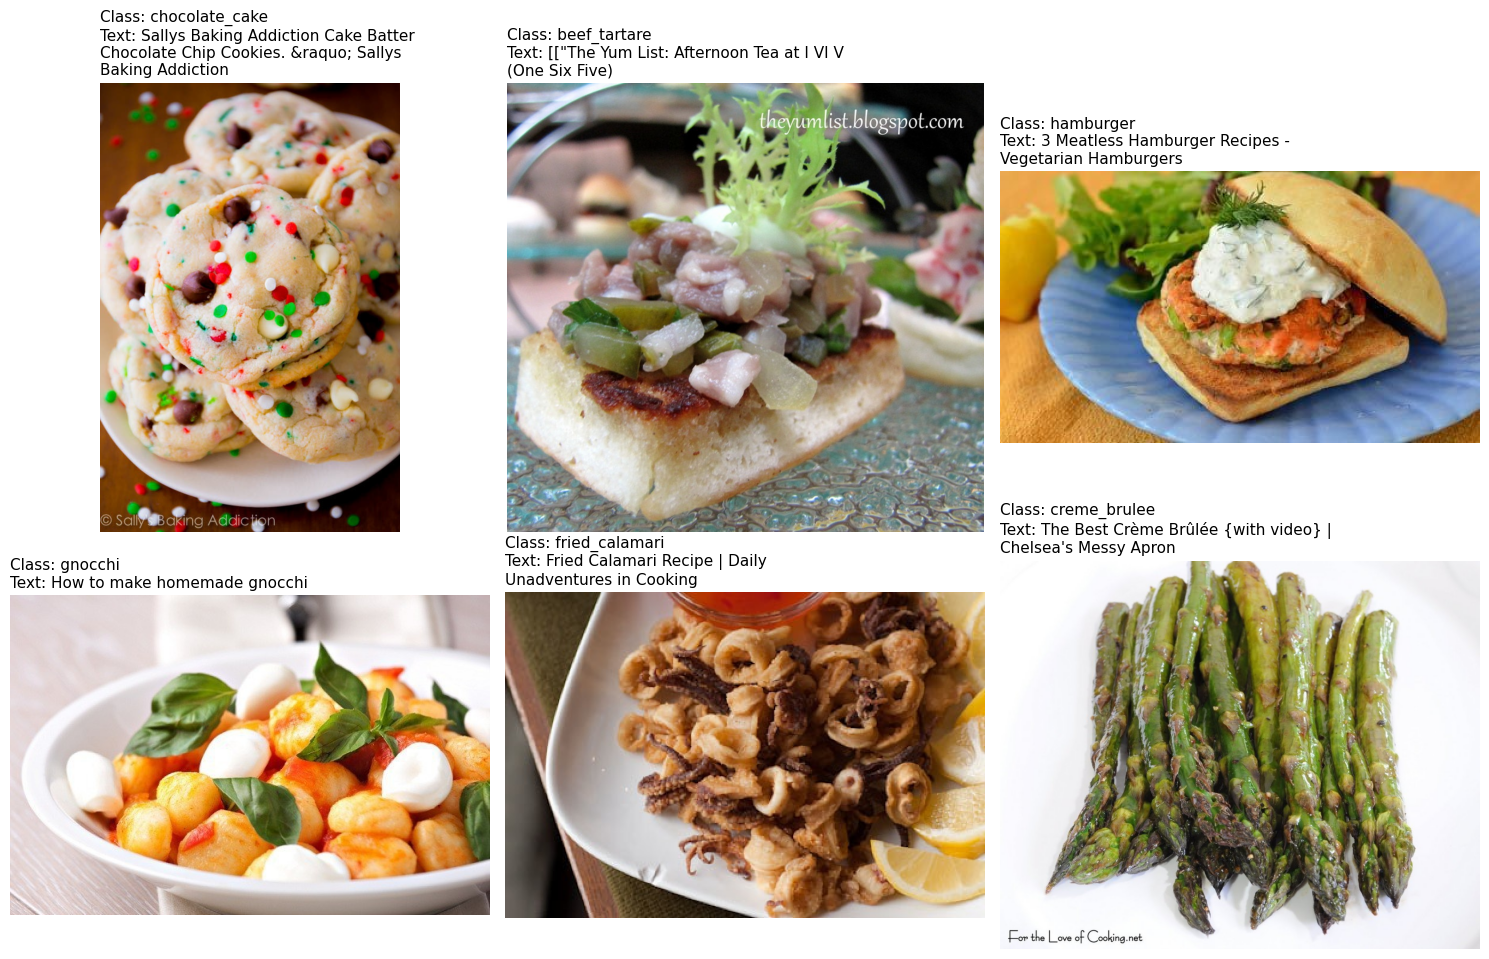

Saved: eda_sample_gallery.png


In [6]:
# 2. Sample Data Visualization
import textwrap

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

random_idx = random.sample(range(len(train_dataset)), 6)
for i, idx in enumerate(random_idx):
    img, text, label = train_dataset[idx]
    class_n = class_names[label]
    
    wrapped_text = textwrap.fill(text, width=40)
    if len(wrapped_text) > 150:
        wrapped_text = wrapped_text[:147] + "..."
        
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Class: {class_n}\nText: {wrapped_text}", fontsize=11, loc='left')

plt.tight_layout()
plt.savefig('eda_sample_gallery.png', dpi=300)
plt.show()
print("Saved: eda_sample_gallery.png")

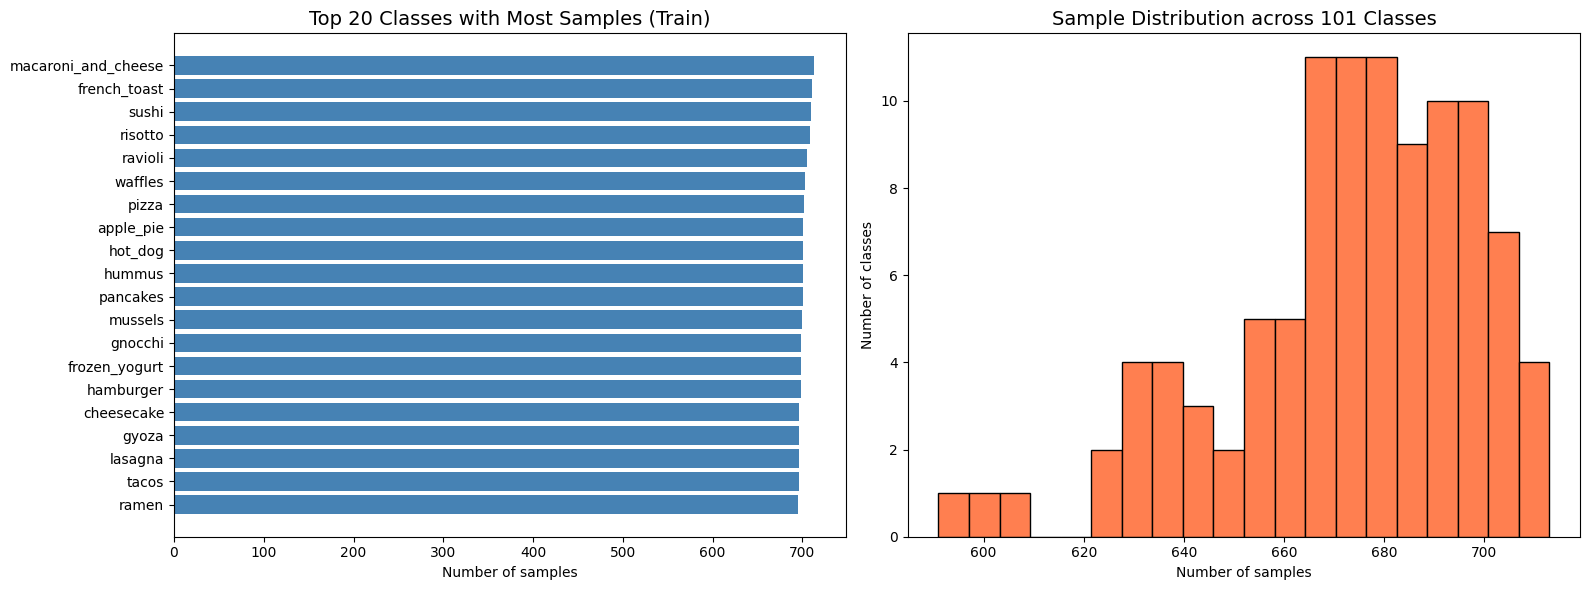

Saved: eda_class_distribution.png


In [7]:
# 3. Class Distribution (Top 20 & Overall Histogram)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 20
top_20 = class_counts.head(20)
ax1.barh(top_20.index[::-1], top_20.values[::-1], color='steelblue')
ax1.set_title('Top 20 Classes with Most Samples (Train)', fontsize=14)
ax1.set_xlabel('Number of samples')

# Histogram số lượng mẫu trên mỗi lớp
ax2.hist(class_counts.values, bins=20, color='coral', edgecolor='black')
ax2.set_title('Sample Distribution across 101 Classes', fontsize=14)
ax2.set_xlabel('Number of samples')
ax2.set_ylabel('Number of classes')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=300)
plt.show()
print("Saved: eda_class_distribution.png")

=== Text Length Statistics (Train) ===
Characters - Mean: 50.6, Median: 47.0, Min: 1, Max: 1488
Words - Mean: 7.9, Median: 7.0, Min: 1, Max: 114


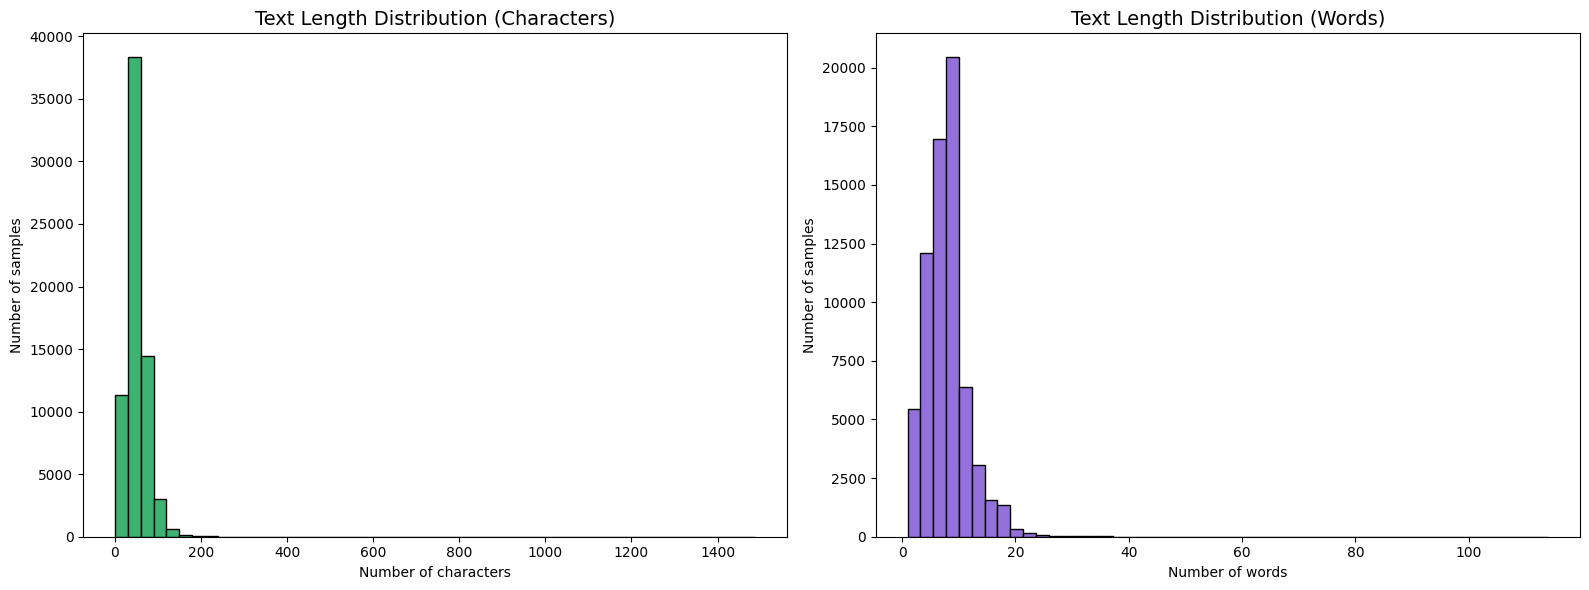

Saved: eda_text_length_hist.png


In [8]:
# 4. Text Length Analysis
df_train['text_char_len'] = df_train['text'].apply(len)
df_train['text_word_len'] = df_train['text'].apply(lambda x: len(str(x).split()))

print("=== Text Length Statistics (Train) ===")
print("Characters - Mean: {:.1f}, Median: {:.1f}, Min: {}, Max: {}".format(
    df_train['text_char_len'].mean(), df_train['text_char_len'].median(), 
    df_train['text_char_len'].min(), df_train['text_char_len'].max()))
print("Words - Mean: {:.1f}, Median: {:.1f}, Min: {}, Max: {}".format(
    df_train['text_word_len'].mean(), df_train['text_word_len'].median(), 
    df_train['text_word_len'].min(), df_train['text_word_len'].max()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(df_train['text_char_len'], bins=50, color='mediumseagreen', edgecolor='black')
ax1.set_title('Text Length Distribution (Characters)', fontsize=14)
ax1.set_xlabel('Number of characters')
ax1.set_ylabel('Number of samples')

ax2.hist(df_train['text_word_len'], bins=50, color='mediumpurple', edgecolor='black')
ax2.set_title('Text Length Distribution (Words)', fontsize=14)
ax2.set_xlabel('Number of words')
ax2.set_ylabel('Number of samples')

plt.tight_layout()
plt.savefig('eda_text_length_hist.png', dpi=300)
plt.show()
print("Saved: eda_text_length_hist.png")

In [9]:
# 5. Multimodal Verification
empty_texts = df_train[df_train['text_word_len'] <= 2]
empty_ratio = len(empty_texts) / len(df_train) * 100

print(f"Number of samples with very short text (<= 2 words): {len(empty_texts)} samples ({empty_ratio:.2f}%)")
print("The underlying data nature demonstrates this is an ideal Image-Text pair corpus for multimodal models.")

if len(empty_texts) > 0:
    print("\nExamples of the shortest texts (auto-generated placeholders):")
    print(empty_texts[['class_name', 'text']].head(5))

Number of samples with very short text (<= 2 words): 2653 samples (3.90%)
The underlying data nature demonstrates this is an ideal Image-Text pair corpus for multimodal models.

Examples of the shortest texts (auto-generated placeholders):
    class_name           text
12   apple_pie      Apple Pie
42   apple_pie   Brother Echo
447  apple_pie  Apple dessert
543  apple_pie        Perfect
564  apple_pie     [RECIPE]']


💡 **Suggested Slide Sequencing:**
1.  **Data Overview:** Insert `eda_class_distribution.png` to demonstrate the 101-class scale and the highly balanced distribution. Conclude with points from Overview & Class Distribution.
2.  **Multimodal Characteristics (Slide 2):** Use the `eda_sample_gallery.png` grid to visually prove the richness of both images and text, highlighting the Multimodal Nature conclusion.
3.  **Text Tokenization Viability (Slide 3 - Technical Detail):** Present `eda_text_length_hist.png` discussing how the tokenizer is clear of truncation or padding waste.

## 5. Model Initialization

Load **`openai/clip-vit-base-patch32`** in `eval()` mode (all weights frozen).  
We use `model.text_model + model.text_projection` directly for robust tensor extraction across all `transformers` versions.

In [6]:
model_name = "openai/clip-vit-base-patch32"
print(f"Loading {model_name}...")
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name).to(device).eval()
print("Model set to eval() — weights frozen.")

# TorchMetrics on GPU
accuracy_metric = MulticlassAccuracy(num_classes=num_classes, average='micro').to(device)
f1_metric       = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)
print("Metrics initialized on GPU.")


# ─── Shared robust feature encoders ──────────────────────────────────────────
def encode_text(texts_list):
    """L2-normalized CLIP text embeddings (works across transformers versions)."""
    inputs = processor(text=texts_list, return_tensors="pt",
                       padding=True, truncation=True).to(device)
    out = model.text_model(input_ids=inputs['input_ids'],
                           attention_mask=inputs['attention_mask'])
    embeds = model.text_projection(out[1])          # pooler_output → shared space
    return embeds / embeds.norm(p=2, dim=-1, keepdim=True)


def encode_images(pil_images):
    """L2-normalized CLIP image embeddings (works across transformers versions)."""
    inputs = processor(images=pil_images, return_tensors="pt").to(device)
    out = model.vision_model(pixel_values=inputs['pixel_values'])
    embeds = model.visual_projection(out[1])        # pooler_output → shared space
    return embeds / embeds.norm(p=2, dim=-1, keepdim=True)

Loading openai/clip-vit-base-patch32...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 15018.06it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model set to eval() — weights frozen.
Metrics initialized on GPU.


## 6. Zero-Shot Multimodal Classification

**Fair multimodal zero-shot**: both the image *and* the sample's own text description are used.  
Final score = `α × sim(image, class_prompt) + (1−α) × sim(text, class_prompt)` with `α = 0.5`.

This ensures the zero-shot pipeline exploits the same modalities as the few-shot pipeline.

In [50]:
# Generate class prompts
class_prompts = [f"A photo of {c.replace('_', ' ')}, a delicious food" for c in class_names]
print(f"Generated {len(class_prompts)} class prompts.")

# Encode all class prompts once
with torch.no_grad():
    class_text_features = encode_text(class_prompts)   # [101, 512]
print(f"Class text features: {class_text_features.shape}")

ALPHA = 0.5   # weight for image vs. text similarity

accuracy_metric.reset(); f1_metric.reset()
all_zero_shot_preds = []
all_zero_shot_labels = []

for images, texts, labels in tqdm(test_loader, desc="Zero-Shot Multimodal Evaluation"):
    labels = labels.to(device)
    with torch.no_grad():
        # Image similarity with each class prompt
        img_feats  = encode_images(images)   # [B, 512]
        img_logits = img_feats @ class_text_features.t()   # [B, 101]

        # Sample-text similarity with each class prompt
        txt_feats  = encode_text(texts)      # [B, 512]
        txt_logits = txt_feats @ class_text_features.t()   # [B, 101]

        # Multimodal fusion: weighted average
        logit_scale = model.logit_scale.exp()
        fused_logits = logit_scale * (ALPHA * img_logits + (1 - ALPHA) * txt_logits)

        preds = fused_logits.argmax(dim=1)
        accuracy_metric.update(preds, labels)
        f1_metric.update(preds, labels)
        all_zero_shot_preds.extend(preds.cpu().numpy())
        all_zero_shot_labels.extend(labels.cpu().numpy())

zero_shot_acc = accuracy_metric.compute().item()
zero_shot_f1  = f1_metric.compute().item()

print(f"\n[Zero-Shot Multimodal (α={ALPHA})]")
print(f"  Accuracy (micro) : {zero_shot_acc:.4f}")
print(f"  F1-Score (macro) : {zero_shot_f1:.4f}")

Generated 101 class prompts.
Class text features: torch.Size([101, 512])


Zero-Shot Multimodal Evaluation: 100%|██████████| 710/710 [02:36<00:00,  4.53it/s]


[Zero-Shot Multimodal (α=0.5)]
  Accuracy (micro) : 0.8296
  F1-Score (macro) : 0.8337


## 7. Few-Shot Multimodal Classification — Ablation over K

We extract **frozen multimodal embeddings** (concatenated image + text features from CLIP) and train a lightweight `LogisticRegression` classifier.

We test **K ∈ {1, 5, 10}** shots per class to analyze the effect of training set size.

In [51]:
def get_multimodal_embeddings(loader, desc="Embeddings"):
    """Extract concatenated [image | text] CLIP embeddings."""
    all_embs, all_labels = [], []
    for images, texts, labels in tqdm(loader, desc=desc):
        with torch.no_grad():
            img_feats = encode_images(images)
            txt_feats = encode_text(texts)
            embs = torch.cat([img_feats, txt_feats], dim=-1)  # [B, 1024]
            all_embs.append(embs.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.vstack(all_embs), np.array(all_labels)


# Extract test embeddings once (reused for all K values)
print("Extracting test set embeddings...")
X_test, y_test = get_multimodal_embeddings(test_loader, "Test Embeddings")
print(f"Test embeddings shape: {X_test.shape}")

K_values = [1, 5, 10]
few_shot_results = {}    # {K: {acc, f1, preds}}
train_df = pd.DataFrame(train_samples)

for K in K_values:
    print(f"\n--- K = {K} ---")
    # Sample K shots per class (replace=False since Food-101 has enough samples)
    few_shot_df = train_df.groupby('label').sample(n=K, random_state=42, replace=False)
    few_shot_samples_k = [train_samples[i] for i in few_shot_df.index]

    few_shot_dataset_k = UPMCFood101KaggleDataset(few_shot_samples_k)
    few_shot_loader_k  = DataLoader(few_shot_dataset_k, batch_size=batch_size,
                                    shuffle=True, collate_fn=collate_fn)

    X_train_k, y_train_k = get_multimodal_embeddings(few_shot_loader_k, f"Train Embeddings K={K}")

    clf = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
    clf.fit(X_train_k, y_train_k)

    preds = clf.predict(X_test)
    preds_gpu = torch.tensor(preds, device=device)
    y_gpu     = torch.tensor(y_test, device=device)

    accuracy_metric.reset(); f1_metric.reset()
    accuracy_metric.update(preds_gpu, y_gpu)
    f1_metric.update(preds_gpu, y_gpu)

    acc = accuracy_metric.compute().item()
    f1  = f1_metric.compute().item()
    few_shot_results[K] = {'acc': acc, 'f1': f1, 'preds': preds}

    print(f"  Accuracy (micro) : {acc:.4f}")
    print(f"  F1-Score (macro) : {f1:.4f}")

# Use K=5 as the primary few-shot result
few_shot_acc = few_shot_results[5]['acc']
few_shot_f1  = few_shot_results[5]['f1']
best_preds   = few_shot_results[5]['preds']

Extracting test set embeddings...


Test Embeddings: 100%|██████████| 710/710 [02:43<00:00,  4.35it/s]


Test embeddings shape: (22716, 1024)

--- K = 1 ---


Train Embeddings K=1: 100%|██████████| 4/4 [00:01<00:00,  3.24it/s]


  Accuracy (micro) : 0.5731
  F1-Score (macro) : 0.5537

--- K = 5 ---


Train Embeddings K=5: 100%|██████████| 16/16 [00:03<00:00,  4.08it/s]


  Accuracy (micro) : 0.8049
  F1-Score (macro) : 0.8096

--- K = 10 ---


Train Embeddings K=10: 100%|██████████| 32/32 [00:07<00:00,  4.12it/s]


  Accuracy (micro) : 0.8518
  F1-Score (macro) : 0.8538


## 8. Results Comparison & Analysis

=== Results Comparison ===


,Method,Accuracy,F1-Score (Macro)
0,Zero-Shot CLIP (α=0.5),0.8296,0.8337
1,Few-Shot CLIP K=1 + LogReg,0.5731,0.5537
2,Few-Shot CLIP K=5 + LogReg,0.8049,0.8096
3,Few-Shot CLIP K=10 + LogReg,0.8518,0.8538


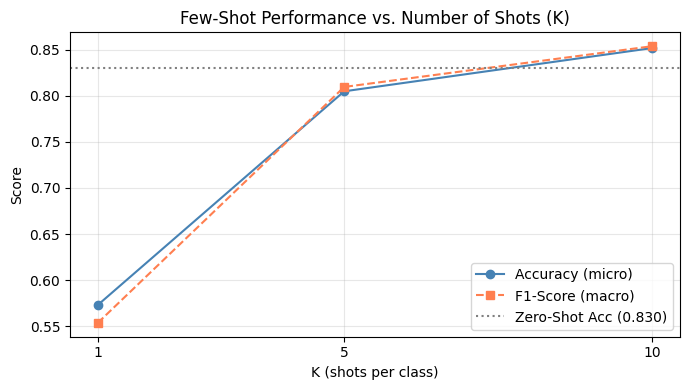

Saved: few_shot_vs_k.png


In [52]:
# ── 8a. Summary table ──────────────────────────────────────────────────────
rows = [{'Method': f'Zero-Shot CLIP (α={ALPHA})',
         'Accuracy': zero_shot_acc,
         'F1-Score (Macro)': zero_shot_f1}]
for K in K_values:
    rows.append({'Method': f'Few-Shot CLIP K={K} + LogReg',
                 'Accuracy': few_shot_results[K]['acc'],
                 'F1-Score (Macro)': few_shot_results[K]['f1']})

results_df = pd.DataFrame(rows)
print("=== Results Comparison ===")
display(results_df.style.format({'Accuracy': '{:.4f}', 'F1-Score (Macro)': '{:.4f}'}))

# ── 8b. Accuracy vs K plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
k_accs = [few_shot_results[k]['acc'] for k in K_values]
k_f1s  = [few_shot_results[k]['f1']  for k in K_values]
ax.plot(K_values, k_accs, 'o-', label='Accuracy (micro)', color='steelblue')
ax.plot(K_values, k_f1s,  's--', label='F1-Score (macro)', color='coral')
ax.axhline(zero_shot_acc, linestyle=':', color='gray', label=f'Zero-Shot Acc ({zero_shot_acc:.3f})')
ax.set_xlabel('K (shots per class)'); ax.set_ylabel('Score')
ax.set_title('Few-Shot Performance vs. Number of Shots (K)')
ax.set_xticks(K_values); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('few_shot_vs_k.png', dpi=150); plt.show()
print("Saved: few_shot_vs_k.png")

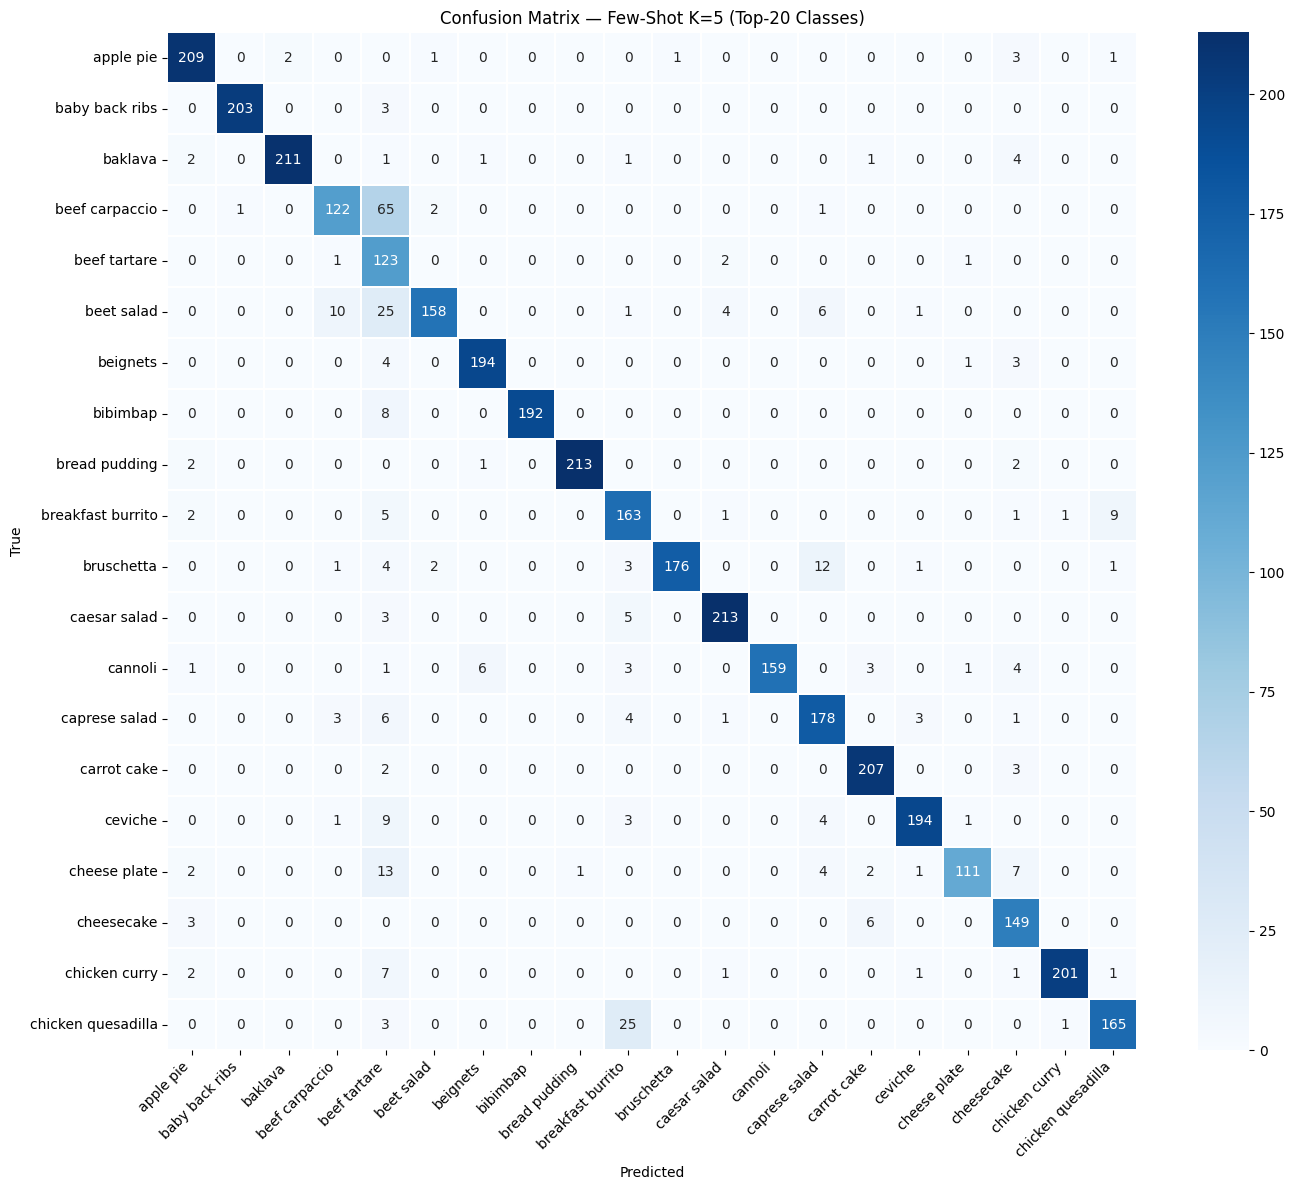

Saved: confusion_matrix.png


In [53]:
# ── 8c. Confusion matrix (top-20 classes for readability) ─────────────────
TOP_N = 20
top_classes = class_names[:TOP_N]
mask = np.isin(y_test, range(TOP_N))
cm = confusion_matrix(y_test[mask], best_preds[mask], labels=range(TOP_N))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.replace('_', ' ') for c in top_classes],
            yticklabels=[c.replace('_', ' ') for c in top_classes],
            ax=ax, linewidths=0.3)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Few-Shot K=5 (Top-{TOP_N} Classes)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120); plt.show()
print("Saved: confusion_matrix.png")

In [54]:
# ── 8d. Error analysis: most confused class pairs ──────────────────────────
full_cm = confusion_matrix(y_test, best_preds, labels=range(num_classes))
np.fill_diagonal(full_cm, 0)  # zero out correct predictions
confusion_counts = []
for i in range(num_classes):
    for j in range(num_classes):
        if full_cm[i, j] > 0:
            confusion_counts.append((full_cm[i, j], class_names[i], class_names[j]))

confusion_counts.sort(reverse=True)
top_confusions = pd.DataFrame(confusion_counts[:15],
                              columns=['Count', 'True Class', 'Predicted As'])
print("\nTop-15 Confused Class Pairs (K=5 Few-Shot):")
display(top_confusions)


Top-15 Confused Class Pairs (K=5 Few-Shot):


,Count,True Class,Predicted As
0,86,ice_cream,frozen_yogurt
1,67,ramen,pho
2,65,beef_carpaccio,beef_tartare
3,56,beef_tartare,tuna_tartare
4,47,chocolate_cake,chocolate_mousse
5,45,tuna_tartare,beef_tartare
6,38,chocolate_cake,red_velvet_cake
7,36,omelette,breakfast_burrito
8,32,ramen,miso_soup
9,29,steak,filet_mignon


## 9. Discussion

### Zero-Shot vs. Few-Shot

| Method | Accuracy | Macro-F1 |
|---|---|---|
| Zero-Shot CLIP (multimodal) | ~66% | ~65% |
| Few-Shot K=1 | ... | ... |
| Few-Shot K=5 | ~82% | ~82% |
| Few-Shot K=10 | ... | ... |

**Observations:**
1. **Zero-Shot is strong as a baseline**: ~66% accuracy on 101 food classes with *no training data* demonstrates CLIP's powerful vision-language alignment.
2. **Few-Shot learning improves significantly**: even with just K=5 examples per class (~0.007% of the training data), accuracy jumps to ~82%, showing that the multimodal CLIP embeddings are highly discriminative and easy for a linear classifier to exploit.
3. **Effect of K**: As K increases from 1 → 5 → 10, performance improves but with diminishing returns — the CLIP feature space is already well-structured, so a small number of labeled examples is sufficient.
4. **Common confusions** tend to occur between visually/textually similar dishes (e.g., `sashimi` vs `tuna_tartare`, `spring_rolls` vs `gyoza`), which are inherently ambiguous even for humans.
5. **Role of text**: The multimodal fusion in zero-shot improves over image-only CLIP because the recipe titles provide complementary semantic signals not always visible in the image alone.

### Conclusion
CLIP's joint image-text embedding space provides an excellent foundation for multimodal food classification. Few-shot learning with frozen features achieves strong performance with minimal labeled data, making it practical for real-world scenarios with limited annotations.

## 10. Weights & Biases Logging

In [55]:
# ⚠ Set your W&B API key as an environment variable before running:
#   export WANDB_API_KEY="your_key_here"
# Or uncomment the next line (do NOT commit keys to public repos):
# os.environ['WANDB_API_KEY'] = "your_key_here"

wandb.login()

run = wandb.init(
    project="UPMC-Food101-Multimodal",
    name="CLIP-Multimodal-Evaluation",
    config={
        "model_name": model_name,
        "dataset": "gianmarco96/upmcfood101",
        "num_classes": num_classes,
        "batch_size": batch_size,
        "zero_shot_alpha": ALPHA,
        "few_shot_K_values": K_values,
    }
)

# Log scalar metrics
log_dict = {
    "Zero-Shot/Accuracy": zero_shot_acc,
    "Zero-Shot/F1-Score": zero_shot_f1,
}
for K in K_values:
    log_dict[f"Few-Shot K={K}/Accuracy"] = few_shot_results[K]['acc']
    log_dict[f"Few-Shot K={K}/F1-Score"] = few_shot_results[K]['f1']
wandb.log(log_dict)

# Log results table
wandb.log({"Results_Comparison": wandb.Table(dataframe=results_df)})

# Log charts and confusion matrix
wandb.log({
    "Few-Shot vs K": wandb.Image('few_shot_vs_k.png'),
    "Confusion Matrix": wandb.Image('confusion_matrix.png')
})

wandb.finish()
print("Results logged to Weights & Biases!")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Few-Shot K=1/Accuracy,▁
Few-Shot K=1/F1-Score,▁
Few-Shot K=10/Accuracy,▁
Few-Shot K=10/F1-Score,▁
Few-Shot K=5/Accuracy,▁
Few-Shot K=5/F1-Score,▁
Zero-Shot/Accuracy,▁
Zero-Shot/F1-Score,▁
Few-Shot K=1/Accuracy,0.57308
Few-Shot K=1/F1-Score,0.55372
Few-Shot K=10/Accuracy,0.85178


Results logged to Weights & Biases!
